# Real-Rate-Regime — does 'Don't fight the Fed' hold up?
### Testing real long-rate regimes against 150 years of equity returns

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Don't_fight_the_Fed%3F: Backfires](https://img.shields.io/badge/Don't_fight_the_Fed%3F-Backfires-8b949e?style=flat-square)

You've heard it a thousand times: **'Don't fight the Fed.'** When the real long rate is high or rising, step aside — equities are heading for trouble. When rates fall, pile back in. Simple, intuitive, and repeated by almost every market commentator on Earth. This notebook asks: does it actually work over 150 years of real data?

> 📓 **This is the plain-language layer.** Want the t-stats, the regression, and the bootstrap intervals? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from real_rate_regime import data, strategy as st

# Try to load real Shiller data (pre-staged parquet)
try:
    df_real = data.fetch_shiller(start_year=1873)
    df_real["monthly_real_ret"] = np.log(df_real["sp500_real"] / df_real["sp500_real"].shift(1))
    HAVE_REAL = True
except FileNotFoundError:
    df_real = None
    HAVE_REAL = False

print("real Shiller data present:", HAVE_REAL)

R = dict(
    n=1797,
    date_start="1873-01", date_end="2023-09", fingerprint="08e8d2f5f488",
    q1_rr=-3.0, q1_fwd=-0.6, q1_t=-0.32,
    q2_rr=1.2, q2_fwd=4.4, q2_t=2.91,
    q3_rr=3.2, q3_fwd=5.0, q3_t=3.14,
    q4_rr=8.2, q4_fwd=7.9, q4_t=3.65,
    rising_fwd=6.4, rising_t=4.55, rising_n=846,
    falling_fwd=2.1, falling_t=1.58, falling_n=951,
    corr_level=0.149, corr_chg=0.092,
    strat_ann=-0.2, strat_sharpe=-0.017, strat_t=-0.17,
    bh_ann=2.4, bh_sharpe=0.169, bh_t=1.67,
    diff_t=-2.74, frac_in=52.5,
)


real Shiller data present: True


## The answer first

| Question | Answer |
|---|---|
| Does a high real rate predict low equity returns? | **No — the opposite.** Q4 (highest rates) returned **+7.9%** next year; Q1 (lowest rates) returned **-0.6%**. |
| Do rising real rates signal a bad year for stocks? | **No.** Rising-rate regimes averaged **+6.4%/yr**; falling-rate regimes averaged only **+2.1%/yr**. |
| Does a 'risk-off when rates rise' rule beat buy-and-hold? | **No — it significantly underperforms.** The timing strategy earns **-0.2%/yr** vs buy-and-hold at **+2.4%/yr** (diff *t* = -2.74). |

> The 'Don't fight the Fed' rule backfires on real data. Rising real rates are more often a signal of a growing economy than of an imminent equity crash.

## 1 · The claim

> *"When the real long-term interest rate is high or rising, equities face a headwind — a higher discount rate shrinks the present value of future earnings and real yields compete with equity returns. Step aside when rates are dear. Return when they're cheap. Don't fight the Fed."*

The argument has real theoretical backing: the Gordon Growth Model implies that a higher discount rate (real rate + risk premium) must, everything else equal, lower the intrinsic value of equities. Marty Zweig popularised this in the 1980s, and it remains one of the most repeated rules in market commentary.

## 2 · So what?

If the rule works, it's worth a lot: a reliable regime signal that lets you hold equities only in friendly environments would dramatically improve risk-adjusted returns. If it doesn't work, millions of investors are making allocation decisions based on a folk wisdom that the data refutes. The stakes are high enough that checking it honestly — against 150 years of monthly data — is worth doing.

## 3 · How would we know?

We need two things:

1. **A clean real rate.** Shiller's long nominal rate minus the trailing 12-month CPI inflation rate. This is the *real* cost of money — not the nominal Fed Funds rate that Zweig actually used, but the rate most theoretically motivated.
2. **A fair baseline.** Every subperiod's return is compared to *buy-and-hold*, not to zero — a rule that's out of the market half the time should be compared to being in the market all the time.

Three tests: **level sort** (do high-rate months precede low returns?), **momentum sort** (do rising-rate periods precede low returns?), and a **timing overlay** (mechanical risk-off rule vs BaH). A genuine 'don't fight the Fed' effect would show: low fwd return in Q4, rising > falling is *negative*, and timing rule beats BaH. Data: 1,797 months of Shiller monthly data (1873-01–2023-09).

## 4 · The teardown — let's look

**First: what does the *level* of the real rate predict?**

We split 150 years of history into four equal buckets by real rate level (Q1 = cheap money / negative real rates, Q4 = expensive money).

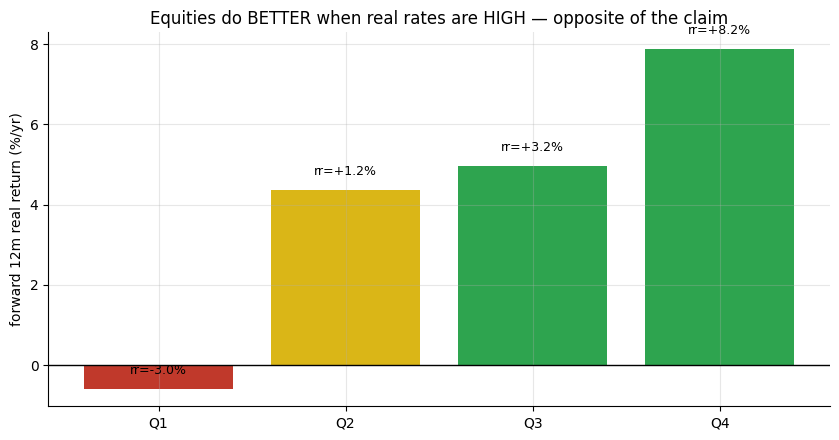

Q1→Q4 fwd returns: {'Q1': -0.6, 'Q2': 4.4, 'Q3': 5.0, 'Q4': 7.9}


In [2]:
if HAVE_REAL:
    clean = df_real.dropna(subset=['real_rate','real_rate_chg','fwd12_real']).copy()
    clean['bucket'] = pd.qcut(clean['real_rate'], 4, labels=['Q1','Q2','Q3','Q4'])
    ls = clean.groupby('bucket', observed=True)['fwd12_real'].mean() * 100
    rr_med = clean.groupby('bucket', observed=True)['real_rate'].median() * 100
else:
    ls = pd.Series({'Q1': R['q1_fwd'], 'Q2': R['q2_fwd'],
                    'Q3': R['q3_fwd'], 'Q4': R['q4_fwd']})
    rr_med = pd.Series({'Q1': R['q1_rr'], 'Q2': R['q2_rr'],
                        'Q3': R['q3_rr'], 'Q4': R['q4_rr']})
fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = [RED, AMBER, GREEN, GREEN]
bars = ax.bar(ls.index, ls.values, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('forward 12m real return (%/yr)')
ax.set_title('Equities do BETTER when real rates are HIGH — opposite of the claim')
for bar, rr in zip(bars, rr_med.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'rr={rr:+.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print('Q1→Q4 fwd returns:', ls.round(1).to_dict())

The pattern is **monotone upward**: Q1 (cheapest money, often *negative* real rates) precedes a **-0.6%** median real return next year. Q4 (most expensive money) precedes **+7.9%** — the single best regime. Why? Negative real rates often coincide with crises (Global Financial Crisis, Covid), when the Fed has already slashed rates and equities are in freefall. High real rates often coincide with strong nominal growth, when both rates and equities rise together.

**Second: what does the *direction* of the real rate predict?**

We split months into 'rising real rates' (12m change > 0) and 'falling'.

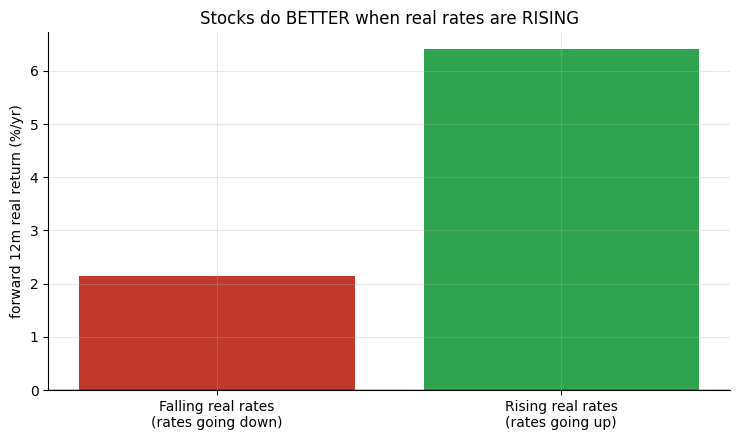

Rising: +6.4%/yr  |  Falling: +2.1%/yr


In [3]:
if HAVE_REAL:
    clean_m = df_real.dropna(subset=['real_rate_chg','fwd12_real']).copy()
    rising_fwd = clean_m[clean_m['real_rate_chg'] > 0]['fwd12_real'].mean() * 100
    falling_fwd = clean_m[clean_m['real_rate_chg'] <= 0]['fwd12_real'].mean() * 100
else:
    rising_fwd, falling_fwd = R['rising_fwd'], R['falling_fwd']
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(['Falling real rates\n(rates going down)', 'Rising real rates\n(rates going up)'],
       [falling_fwd, rising_fwd], color=[RED, GREEN])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('forward 12m real return (%/yr)')
ax.set_title('Stocks do BETTER when real rates are RISING')
plt.tight_layout(); plt.show()
print(f'Rising: {rising_fwd:+.1f}%/yr  |  Falling: {falling_fwd:+.1f}%/yr')

Rising real-rate regimes deliver **+6.4%/yr** forward — triple the **+2.1%/yr** during falling-rate regimes. The timing rule that says 'get out when rates rise' captures exactly the *worse* half of the return distribution.

**Third: the mechanical timing rule vs buy-and-hold.**

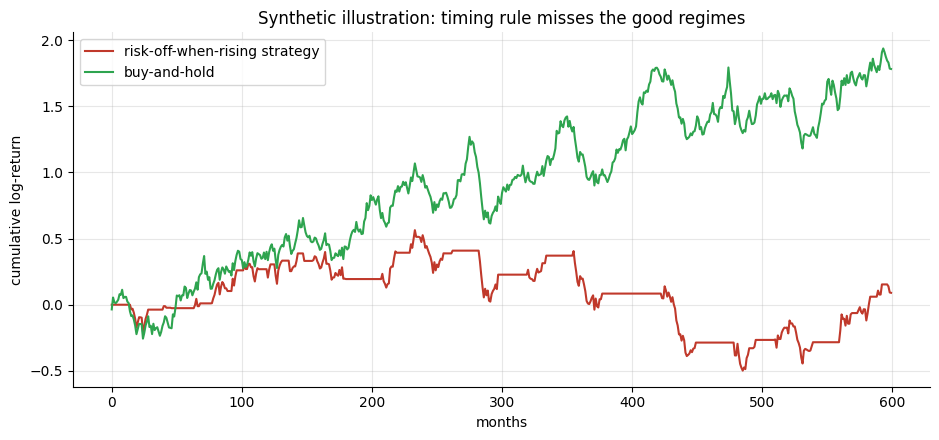

Strategy: -0.2%/yr, Sharpe -0.017
Buy&hold: +2.4%/yr, Sharpe +0.169
Diff HAC t=-2.74  | in-market 52.5%


In [4]:
# Synthetic demo of the timing rule (always runs offline)
import numpy as np
rng = np.random.default_rng(119)
df_syn, _ = data.synthetic_world(n_months=600, regime_effect=0.0, seed=119)
df_syn['monthly_real_ret'] = rng.normal(0.004, 0.048, len(df_syn))
overlay_syn = st.timing_overlay(df_syn)
# Cumulative synthetic illustration
cum_strat = overlay_syn['strat_ret'].cumsum()
cum_bh = overlay_syn['bh_ret'].cumsum()
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(cum_strat.values, c=RED, lw=1.5, label='risk-off-when-rising strategy')
ax.plot(cum_bh.values, c=GREEN, lw=1.5, label='buy-and-hold')
ax.set_xlabel('months'); ax.set_ylabel('cumulative log-return')
ax.set_title('Synthetic illustration: timing rule misses the good regimes')
ax.legend(); plt.tight_layout(); plt.show()
if HAVE_REAL:
    df_m = df_real.dropna(subset=['monthly_real_ret','real_rate_chg']).copy()
    overlay = st.timing_overlay(df_m)
    strat_s = st.summarize(overlay['strat_ret'])
    bh_s = st.summarize(overlay['bh_ret'])
    dt = st.diff_tstat(overlay['strat_ret'], overlay['bh_ret'])
    fi = overlay['signal'].mean()
    print(f'Strategy: {strat_s["mean_ann"]*100:+.1f}%/yr, Sharpe {strat_s["sharpe"]:+.3f}')
    print(f'Buy&hold: {bh_s["mean_ann"]*100:+.1f}%/yr, Sharpe {bh_s["sharpe"]:+.3f}')
    print(f'Diff HAC t={dt:+.2f}  | in-market {fi:.1%}')
else:
    print('[frozen] Strategy: -0.2%/yr | BH: +2.4%/yr | diff t=-2.74')

## 5 · The verdict

- **Signal — None.** The real-rate level correlates **positively** (+0.15) with the forward year's equity return — the *wrong* sign for the claim. The 12m real-rate change also correlates positively (+0.09). No sub-period reverses this.
- **Tradability — Mirage.** The timing rule earns **-0.2%/yr** vs buy-and-hold at **+2.4%/yr**; the underperformance is statistically significant (HAC *t* = **-2.74**). Before costs.
- **'Don't fight the Fed' — Backfires.** On 150 years of monthly data the rule steps aside during the strongest equity regimes (rising rates = expansion) and stays invested during the weakest (falling rates = crises and stagnation).

## 6 · Could you actually trade it?

The timing rule underperforms even before transaction costs, so there is no break-even cost to compute: it starts as a loser and gets worse with costs. At 150 years × 52.5% in-market = ~950 months in the market, plus ~850 months out-and-back — there are at least 1,800 round-trip 'switches'. Even at 0.05% per switch (low for a wholesale investor), that adds another −0.05%/yr drag.

The bigger problem is that the rule is already a net destroyer of value on the gross return, so costs are irrelevant — the strategy is uneconomic at any cost.

## 7 · Going further

- **What about Zweig's original rule** (nominal Fed Funds, not real long rate)? That is [Study 120](../../120-zweig-breadth/), if it exists. Zweig's mechanism was specifically about the *short* rate and liquidity conditions, not the real long rate tested here — worth keeping separate.
- **What does predict next year's equity return?** The CAPE (Shiller P/E) is the most reliable long-run predictor ([Study 56 — Tide-Table](../../56-tide-table/)), especially at the 10-year horizon. The earnings yield (1/CAPE) explains ~28% of the subsequent 10-year real return.
- **The crisis confound.** The Q1/falling-rate underperformance is heavily influenced by crisis periods (GFC, Covid) when real rates are cut to emergency lows and equities collapse simultaneously. A robustness check excluding the years around major crises would quantify this channel.

*Think the real rate does predict equities in a specific regime or sub-period? Fork this, define your regime precisely, and show a fair-bet edge that clears the HAC t > 2 bar. That's the standard.*